# Intelligent AOM: Documentation PB Implementation

## Summary

This notebook implements the workflow described in `Intelligent_AOM___Documentation_PB.pdf`. It samples random AWG input spectra, simulates the AOM output with the PB sine-response model, and trains a neural network to solve the inverse problem: from a desired/simulated AOM output spectrum back to the AWG coefficients that should create it.

`QUICK_RUN = True` keeps the experiments small enough for a fast CPU run; `QUICK_RUN = False` uses larger dataset sizes and longer training runs for report-style figures.

## Signal Model

The AWG input spectrum is represented by 11 complex tones at frequencies

$$f_i \in \{95, 96, \ldots, 105\}\ \mathrm{MHz}.$$

Each training target is a 22-dimensional real vector

$$y = [a_1, \ldots, a_{11}, b_1, \ldots, b_{11}] \in \mathbb{R}^{22},$$

where $a_i$ and $b_i$ are the real and imaginary tone weights. Following the PB documentation, the raw coefficients are sampled uniformly from $[-0.5, 0.5]$ and then normalized to a selected input-vector norm:

$$y \leftarrow \alpha\,\frac{y}{\lVert y \rVert_2},$$

with the PB baseline $\alpha=0.1$. Larger norms increase the nonlinearity of the simulated AOM response.

The time-domain AWG amplitude modulation signal is reconstructed as

$$AM(t) = \sum_{i=1}^{11} a_i\cos(2\pi f_i t) - \sum_{i=1}^{11} b_i\sin(2\pi f_i t).$$

In the PB model, the nonlinear AOM/RF response is simulated as

$$RF(t) = \sin\left(2\pi AM(t)\right).$$

The AOM output spectrum is sampled at 101 frequencies from 50 to 150 MHz. The complex FFT samples are stored as real and imaginary parts, giving the 202 real-valued input features described in the PB documentation.

$$S_k = \frac{1}{L/2}\,\mathcal{F}\{RF(t)\}_k,$$

$$X = [\Re(S_{k_1}), \ldots, \Re(S_{k_m}), \Im(S_{k_1}), \ldots, \Im(S_{k_m})] \in \mathbb{R}^{2m},$$

where $m=101$ for the PB feature representation.

## Learning Problem

The neural network learns the inverse mapping

$$\hat{y} = g_\theta(X), \qquad g_\theta: \mathbb{R}^{2m} \to \mathbb{R}^{22}.$$

The default architecture is a fully connected model

$$2m \to 1024 \to 128 \to 64 \to 22,$$

with batch normalization and LeakyReLU activations after the hidden linear layers. Training uses Adam with learning rate $10^{-3}$ and weight decay $10^{-5}$. Depending on the experiment, the loss is either mean absolute error

$$\mathcal{L}_{MAE}=\frac{1}{N}\sum_{n=1}^{N}\lVert g_\theta(X_n)-y_n\rVert_1,$$

or mean squared error

$$\mathcal{L}_{MSE}=\frac{1}{N}\sum_{n=1}^{N}\lVert g_\theta(X_n)-y_n\rVert_2^2.$$

## What The Notebook Produces

1. Figure III.1 compares a target AWG input spectrum against the network-predicted AWG input spectrum and plots the training/validation curve.
2. Figure III.2 visualizes both training and validation MAE as dataset size and input norm change.
3. Figure III.3 measures how validation MAE changes as the first hidden-layer width is varied.
4. The final section visualizes the PB sine-response simulator by comparing $AM(t)$, $RF(t)=\sin(2\pi AM(t))$, and their spectra.

In [29]:
import random
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, random_split

SEED = 42  # Random seed used for reproducible sampling, splitting, and training initialization.
QUICK_RUN = False  # Set True for small, fast demo runs; set False for report-scale experiments.
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # Compute device used by PyTorch.

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True})  # Global plot resolution and grid style.
print('device:', DEVICE)

device: cuda


## AOM Simulator

In [30]:
DT, L = 1e-3, int(1e5)  # Time step in microseconds and number of samples in the simulated waveform.
F0, DFM, NM = 100.0, 0.1, 200  # Center frequency, modulation-frequency spacing, and frequency-grid width from PB.
PB_BASE_NORM = 0.1  # Baseline AWG input-vector norm used for the successful PB model.

t = np.arange(L) * DT
f = np.arange(L // 2) * (1 / DT / L)
fm = F0 + np.arange(-NM // 2, NM // 2 + 1) * DFM
awg_freqs = np.arange(95.0, 106.0, 1.0)  # AWG input-tone frequencies, in MHz, used as the target spectrum.
out_freqs = np.linspace(50.0, 150.0, 101)  # PB AOM output window: 101 complex tones from 50 to 150 MHz.

df = 1 / DT / L
out_bins = np.rint(out_freqs / df).astype(int)  # FFT bin indices corresponding to the PB output frequencies.
awg_idx = (NM // 2 + np.rint((awg_freqs - F0) / DFM)).astype(int)


COS = np.cos(2 * np.pi * fm[awg_idx, None] * t)
SIN = np.sin(2 * np.pi * fm[awg_idx, None] * t)

def sample_awg(n, norm=PB_BASE_NORM):  # n is the number of random AWG spectra; norm is the target coefficient-vector norm.
    y = (np.random.rand(n, 22) - 0.5).astype(np.float32)
    y /= np.linalg.norm(y, axis=1, keepdims=True)
    return norm * y

def simulate_awg(x):
    am = x[:11] @ COS - x[11:] @ SIN
    rf = np.sin(2 * np.pi * am)
    spectrum = np.fft.fft(rf) / (L / 2)
    features = np.r_[spectrum[out_bins].real, spectrum[out_bins].imag].astype(np.float32)
    return am, rf, spectrum[:L // 2], features

def make_dataset(n, norm=PB_BASE_NORM):
    y = sample_awg(n, norm)
    X = np.array([simulate_awg(row)[3] for row in y], dtype=np.float32)
    return X, y

print(f'AWG target: {len(awg_freqs)} complex tones = 22 values')
print(f'AOM feature: {len(out_freqs)} complex tones = {2 * len(out_freqs)} values')

AWG target: 11 complex tones = 22 values
AOM feature: 101 complex tones = 202 values


## PB Sine-Response Simulator

Before training the inverse model, it is useful to inspect the forward simulator that creates the dataset. This section shows how one sampled AWG input spectrum is converted into the time-domain modulation signal $AM(t)$, then into the nonlinear PB response $RF(t)=\sin(2\pi AM(t))$, and finally into the AOM output spectrum used as the neural-network input.


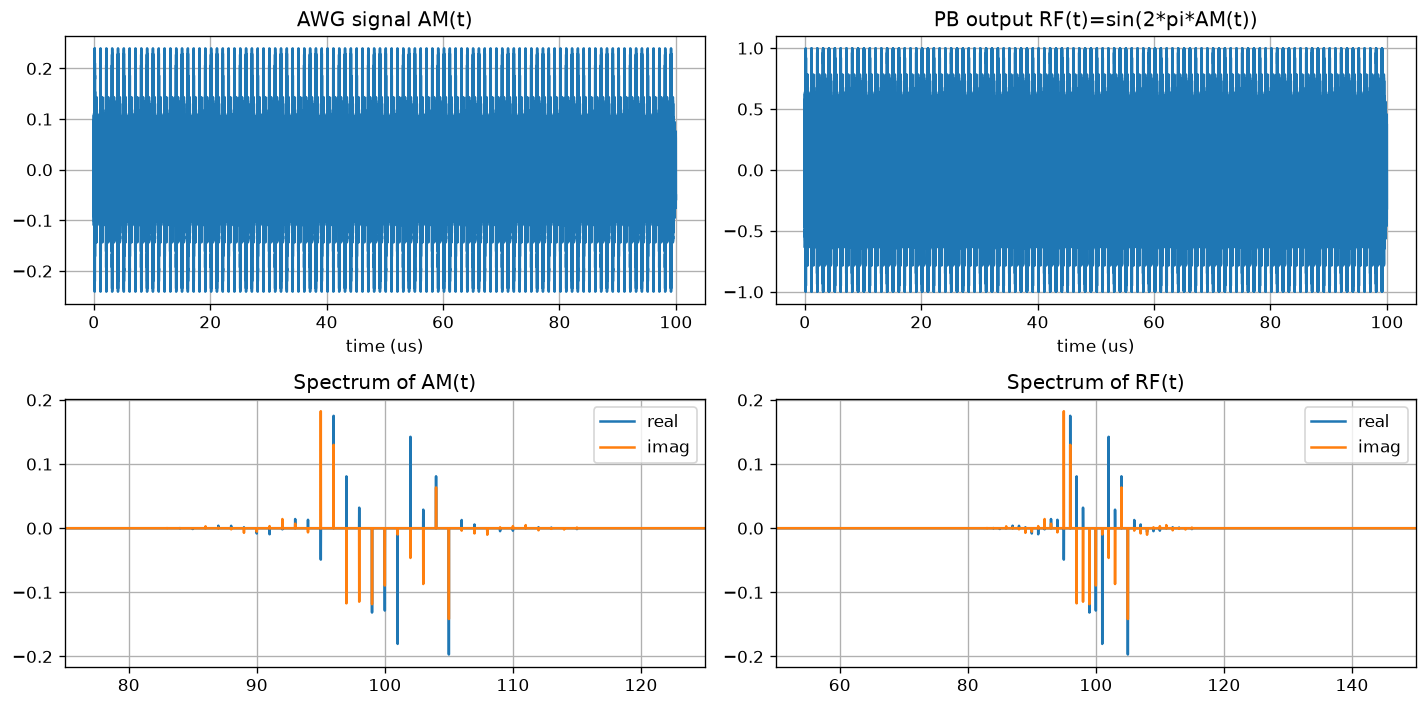

In [31]:
x = sample_awg(1, norm=PB_BASE_NORM)[0]  # One example AWG coefficient vector used for the PB sine-response visualization.
AM, RF, spectrum_AM, _ = simulate_awg(x)
spectrum_RF = np.fft.fft(RF)[:L // 2] / (L / 2)

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes[0, 0].plot(t, AM)
axes[0, 0].set_title('AWG signal AM(t)')
axes[0, 0].set_xlabel('time (us)')

axes[0, 1].plot(t, RF)
axes[0, 1].set_title('PB output RF(t)=sin(2*pi*AM(t))')
axes[0, 1].set_xlabel('time (us)')

axes[1, 0].plot(f, spectrum_AM.real, label='real')
axes[1, 0].plot(f, spectrum_AM.imag, label='imag')
axes[1, 0].set_xlim(75, 125)
axes[1, 0].set_title('Spectrum of AM(t)')
axes[1, 0].legend()

axes[1, 1].plot(f, spectrum_RF.real, label='real')
axes[1, 1].plot(f, spectrum_RF.imag, label='imag')
axes[1, 1].set_xlim(50, 150)
axes[1, 1].set_title('Spectrum of RF(t)')
axes[1, 1].legend()

fig.tight_layout()
plt.show()

## Training Helper

In [32]:
def build_model(input_dim=202, hidden=(1024, 128, 64)):  # input_dim is the feature length; hidden sets the dense-layer widths.
    layers = []
    last = input_dim
    for width in hidden:
        layers += [nn.Linear(last, width), nn.BatchNorm1d(width), nn.LeakyReLU()]
        last = width
    layers.append(nn.Linear(last, 22))
    return nn.Sequential(*layers)

def train_model(X, y, hidden=(1024, 128, 64), epochs=12, loss='mae'):  # hidden, epochs, and loss define the training experiment.
    data = TensorDataset(torch.tensor(X), torch.tensor(y))
    n_val = max(1, len(data) // 5)  # Validation-set size: one fifth of the generated dataset.
    train_ds, val_ds = random_split(data, [len(data) - n_val, n_val], generator=torch.Generator().manual_seed(SEED))
    train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)  # Training mini-batch size.
    val_loader = DataLoader(val_ds, batch_size=256)  # Validation mini-batch size.

    model = build_model(input_dim=X.shape[1], hidden=hidden).to(DEVICE)
    criterion = nn.L1Loss() if loss == 'mae' else nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)  # Adam learning rate and L2 regularization.
    history = {'train': [], 'val': []}

    for _ in range(epochs):
        model.train()
        train_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            batch_loss = criterion(model(xb), yb)
            batch_loss.backward()
            optimizer.step()
            train_loss += batch_loss.item() * len(xb)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                val_loss += criterion(model(xb), yb).item() * len(xb)

        history['train'].append(train_loss / len(train_ds))
        history['val'].append(val_loss / len(val_ds))

    return model, history

def predict(model, X):
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(X, dtype=torch.float32, device=DEVICE)).cpu().numpy()

## Figure III.1: Target and Predicted AWG Spectrum

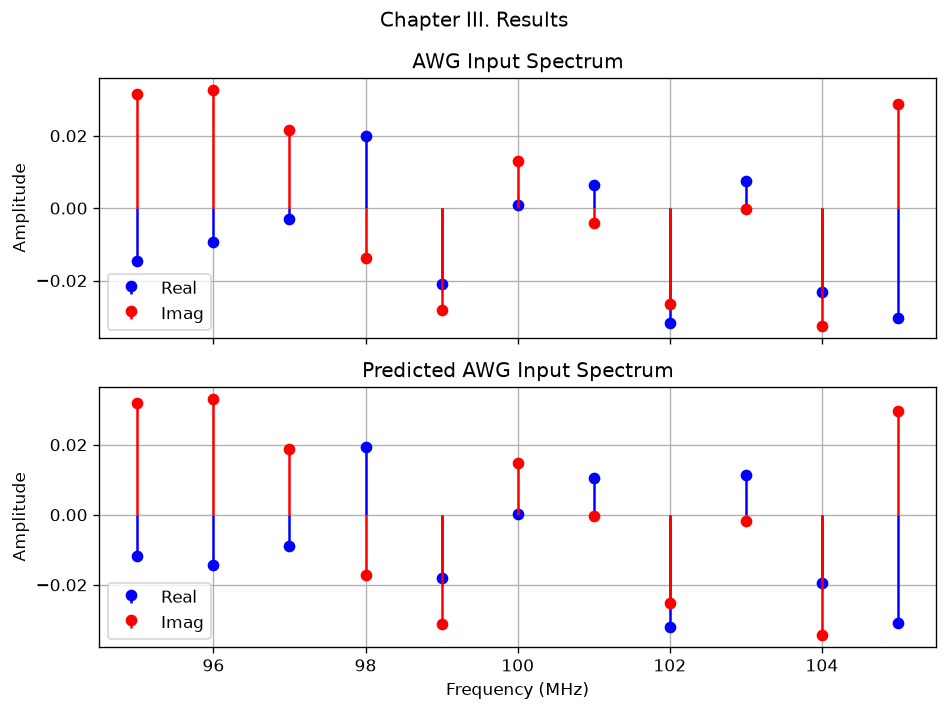

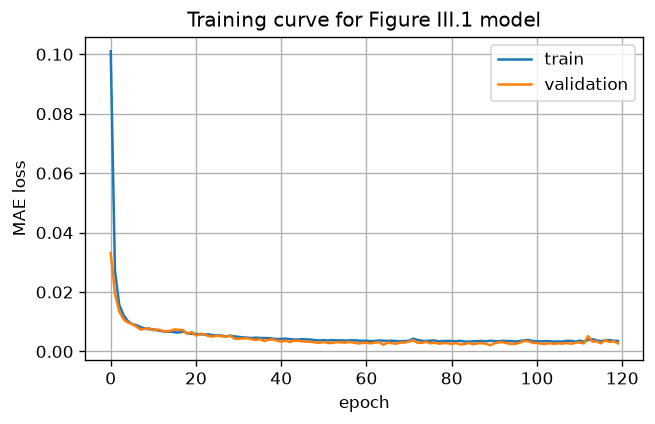

In [33]:
X, y = make_dataset(400 if QUICK_RUN else 10000, norm=PB_BASE_NORM)  # Dataset size and PB baseline AWG input norm for the Figure III.1 model.
model, history = train_model(X, y, epochs=12 if QUICK_RUN else 120)  # Training length for the Figure III.1 model.
target = y[0]
pred = predict(model, X[:1])[0]

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
for ax, values, title in [
    (axes[0], target, 'AWG Input Spectrum'),
    (axes[1], pred, 'Predicted AWG Input Spectrum'),
]:
    ax.stem(awg_freqs, values[:11], linefmt='b-', markerfmt='bo', basefmt=' ', label='Real')
    ax.stem(awg_freqs, values[11:], linefmt='r-', markerfmt='ro', basefmt=' ', label='Imag')
    ax.set_title(title)
    ax.set_ylabel('Amplitude')
    ax.legend()

axes[1].set_xlabel('Frequency (MHz)')
fig.suptitle('Chapter III. Results')
fig.tight_layout()
plt.show()

plt.figure(figsize=(6, 3.5))
plt.plot(history['train'], label='train')
plt.plot(history['val'], label='validation')
plt.title('Training curve for Figure III.1 model')
plt.xlabel('epoch')
plt.ylabel('MAE loss')
plt.legend()
plt.show()

## Figure III.2: Loss vs Dataset Size at Different Input Norms

norm=0.1, samples=1000
norm=0.1, samples=5000
norm=0.1, samples=10000
norm=0.2, samples=1000
norm=0.2, samples=5000
norm=0.2, samples=10000
norm=0.3, samples=1000
norm=0.3, samples=5000
norm=0.3, samples=10000
norm=0.4, samples=1000
norm=0.4, samples=5000
norm=0.4, samples=10000


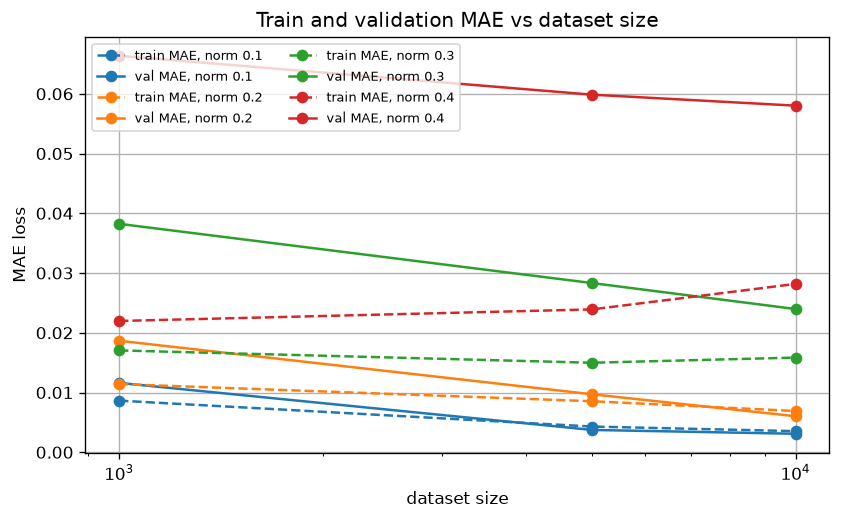

In [34]:
norms = [0.1, 0.2, 0.3, 0.4]  # AWG coefficient-vector norms swept in the PB hyperparameter experiment.
sizes = [200, 500, 1000] if QUICK_RUN else [1000, 5000, 10000]  # Training-set sizes swept in the dataset-size experiment.
epochs = 8 if QUICK_RUN else 100  # Training epochs used for each dataset-size/norm run.

train_losses = {norm: [] for norm in norms}
val_losses = {norm: [] for norm in norms}
for norm in norms:
    for size in sizes:
        print(f'norm={norm}, samples={size}')
        Xn, yn = make_dataset(size, norm=norm)
        _, hist = train_model(Xn, yn, epochs=epochs, loss='mae')
        train_losses[norm].append(hist['train'][-1])
        val_losses[norm].append(hist['val'][-1])

plt.figure(figsize=(8, 4.5))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
for idx, norm in enumerate(norms):
    color = colors[idx % len(colors)]
    plt.plot(sizes, train_losses[norm], 'o--', color=color, label=f'train MAE, norm {norm}')
    plt.plot(sizes, val_losses[norm], 'o-', color=color, label=f'val MAE, norm {norm}')
plt.xscale('log')
plt.title('Train and validation MAE vs dataset size')
plt.xlabel('dataset size')
plt.ylabel('MAE loss')
plt.legend(ncol=2, fontsize=8)
plt.show()

## Figure III.3: Loss vs Layer Size

first hidden layer width=64
first hidden layer width=128
first hidden layer width=256
first hidden layer width=512
first hidden layer width=1024
first hidden layer width=2048
first hidden layer width=4096
first hidden layer width=8192
first hidden layer width=16384


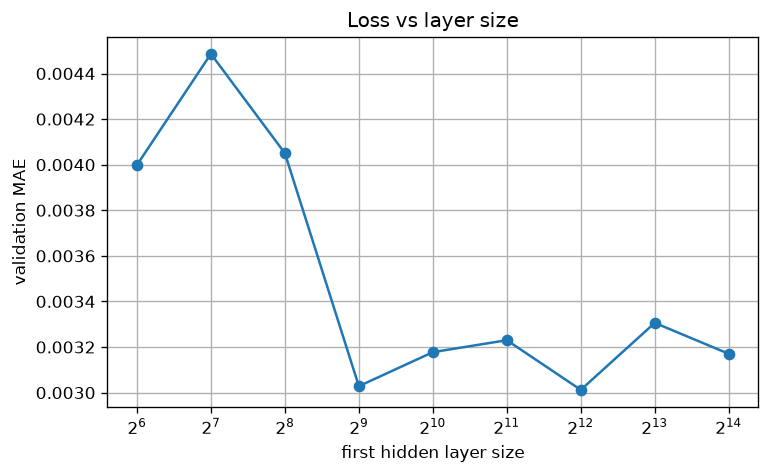

In [35]:
widths = [64, 128, 256, 512, 1024] if QUICK_RUN else [64, 128, 256, 512, 1024, 2048, 4096, 8192, 16_384]  # First hidden-layer widths swept in Figure III.3.
X_layer, y_layer = make_dataset(500 if QUICK_RUN else 10_000, norm=PB_BASE_NORM)  # Shared PB-baseline dataset for the layer-width sweep.

layer_losses = []
for width in widths:
    print(f'first hidden layer width={width}')
    _, hist = train_model(X_layer, y_layer, hidden=(width, 128, 64), epochs=8 if QUICK_RUN else 80)  # Sweeps only the first layer; later layers stay fixed.
    layer_losses.append(hist['val'][-1])

plt.figure(figsize=(7, 4))
plt.plot(widths, layer_losses, 'o-')
plt.xscale('log', base=2)
plt.title('Loss vs layer size')
plt.xlabel('first hidden layer size')
plt.ylabel('validation MAE')
plt.show()